## 1. Business Understanding

Every quarter, the ABS publishes CPI and the RBA reacts to it, or more precisely, to its
own forecast of it, since policy takes months to affect. Three things make this project's
question harder than just "fit a time series model":

- **Two targets, not one.** Headline CPI is full price-change distribution; trimmed-mean CPI is what
  the RBA actually watches for the *underlying* inflation trend, since it discards the
  volatile top/bottom 15% of the price-change distribution each quarter.
- **A moving external benchmark.** The RBA publishes its own CPI forecasts in the
  quarterly Statement on Monetary Policy, a credible institutional baseline this project's
  models are expected to compete against, not just a naive seasonal average.
- **Structure vs. accuracy are different jobs.** Predicting *how much* CPI will move
  ([SARIMA](04_modeling/41_sarima), [Elastic Net](04_modeling/42_elastic_net),
  [Ensemble](04_modeling/43_ensemble)) is a different exercise from explaining *why* it moved, or
  what a hypothetical shock would do to it ([SVAR](04_modeling/44_svar), the [scenario engine](04_modeling/45_scenario_engine)). Conflating the two
  is a common way forecasting projects overstate what they've shown.

This isn't asserted for free: [Appendix §6: Lead-Lag Correlation Analysis](appendix_eda/06_lead_lag_correlation) and [Appendix §7: Granger Causality Screening](appendix_eda/07_granger_causality) for exactly this relationship, whether the candidate macro indicators actually lead CPI, and whether that lead survives a formal causality test, before any forecasting model is fit on them.

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
BLUE, PLUM, MUTED, ALERT = "#5b6f8f", "#8a4f8a", "#9aa79f", "#c0392b"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

import matplotlib.dates as mdates

def year_axis(ax, step=5):
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

CURATED = PROJECT_ROOT / "data" / "curated" / "quarterly_macro_features.csv"
TABLEAU = PROJECT_ROOT / "reports" / "tableau"

The first bullet in one picture: the gap between the two measures is the volatile part of the price-change distribution that the trimmed mean discards, and it spikes at the GST introduction and around the 2020 childcare shock.

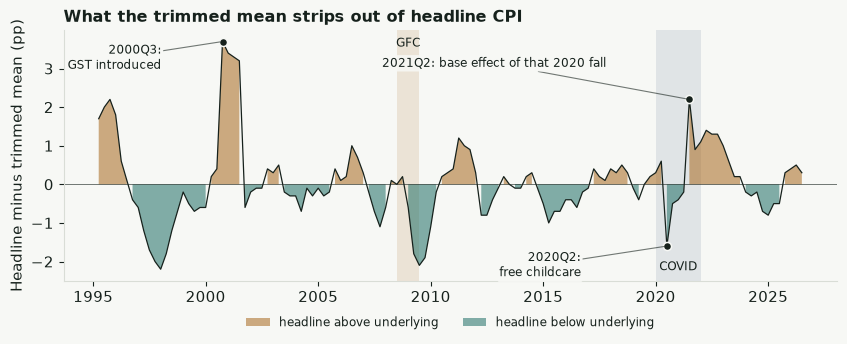

In [2]:
def shade_events(ax, label=False, where="top", windows=None, alpha=0.14):
    """GFC and COVID as light full-height bands: one definition of the periods and colours for the whole book.
    label=True also names each band in plain text (do that once per figure); `where` is "top" or "bottom"
    (or a {name: position} dict); `windows` overrides {name: (first quarter, last quarter, colour)}."""
    periods = {"GFC": ("2008Q3", "2009Q3", "#a8691f"), "COVID": ("2020Q1", "2022Q1", "#5b6f8f")}
    periods.update(windows or {})
    for name, (start, end, colour) in periods.items():
        s, e = pd.Period(start, "Q").to_timestamp(), pd.Period(end, "Q").to_timestamp()
        ax.axvspan(s, e, color=colour, alpha=alpha, linewidth=0, zorder=0)
        if label:
            pos = where.get(name, "top") if isinstance(where, dict) else where
            ax.text(s + (e - s) / 2, 0.97 if pos == "top" else 0.03, name, transform=ax.get_xaxis_transform(), ha="center",
                    va="top" if pos == "top" else "bottom", fontsize=8.5, color="#16211c", zorder=1)


def mark_time(ax, x, y, label, offset, ha="left", size=8.5):
    """A dot on the exact point (x, y) and a thin leader line to a text label `offset` points away."""
    ax.scatter([x], [y], s=34, color=INK, edgecolor=PAPER, linewidth=1.1, zorder=6, clip_on=False)
    ax.annotate(label, (x, y), xytext=offset, textcoords="offset points", ha=ha, va="center", fontsize=size, zorder=7,
                bbox=dict(boxstyle="round,pad=0.15", facecolor=PAPER, edgecolor="none", alpha=0.9),
                arrowprops=dict(arrowstyle="-", color=INK, alpha=0.6, linewidth=0.8, shrinkA=0, shrinkB=2))

df = pd.read_csv(CURATED).dropna(subset=["cpi_yoy", "trimmed_mean_cpi_yoy"])
df["date"] = pd.PeriodIndex(df["quarter"], freq="Q").to_timestamp(how="end")
gap = df["cpi_yoy"] - df["trimmed_mean_cpi_yoy"]

fig, ax = plt.subplots(figsize=(8.6, 3.6))
ax.axhline(0, color=INK, linewidth=0.7, alpha=0.6)
shade_events(ax, label=True, where={"GFC": "top", "COVID": "bottom"})
ax.fill_between(df["date"], gap, 0, where=gap >= 0, color=HIGHLIGHT, alpha=0.55, linewidth=0, label="headline above underlying")
ax.fill_between(df["date"], gap, 0, where=gap < 0, color=ACCENT, alpha=0.55, linewidth=0, label="headline below underlying")
ax.plot(df["date"], gap, color=INK, linewidth=0.9)

events = [   # (label, window start, window end, label offset in points)
    ("2000Q3:" + chr(10) + "GST introduced", "2000-06-30", "2001-06-30", (-44, -12)),
    ("2020Q2:" + chr(10) + "free childcare", "2020-03-31", "2020-09-30", (-62, -14)),
    ("2021Q2: base effect of that 2020 fall", "2021-03-31", "2021-09-30", (-60, 26)),
]
for label, lo, hi, offset in events:
    w = gap[(df["date"] >= lo) & (df["date"] <= hi)]
    i = w.abs().idxmax()
    mark_time(ax, df.loc[i, "date"], gap[i], label, offset, ha="left" if offset[0] > 0 else "right")
ax.set_ylabel("Headline minus trimmed mean (pp)")
ax.set_title("What the trimmed mean strips out of headline CPI", loc="left", fontsize=11.5, fontweight="bold")
ax.legend(frameon=False, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)
ax.grid(axis="x", visible=False)
year_axis(ax, 5)
fig.tight_layout()
ax.grid(False)
plt.show()

**Success criteria**, previewed here so every later section can be read against them:

$$\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^n (y_i-\hat y_i)^2}$$

$$P(\text{lower} \le y \le \text{upper}) \approx 0.80$$

$$\text{macro-F1} = \tfrac{1}{3}\sum_{c\in\{cut,hold,hike\}} F1_c$$

- Point-forecast accuracy per horizon vs. seasonal-naive 
- RBA nominal 80% interval coverage 
- The RBA policy-action classifier's class-balanced F1.

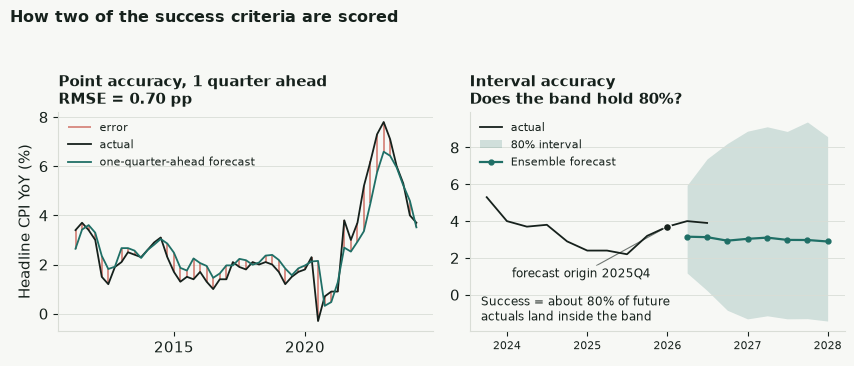

In [ ]:
def mark_time(ax, x, y, label, offset, ha="left", size=8.5):
    """A dot on the exact point (x, y) and a thin leader line to a text label `offset` points away."""
    ax.scatter([x], [y], s=34, color=INK, edgecolor=PAPER, linewidth=1.1, zorder=6, clip_on=False)
    ax.annotate(label, (x, y), xytext=offset, textcoords="offset points", ha=ha, va="center", fontsize=size, zorder=7,
                bbox=dict(boxstyle="round,pad=0.15", facecolor=PAPER, edgecolor="none", alpha=0.9),
                arrowprops=dict(arrowstyle="-", color=INK, alpha=0.6, linewidth=0.8, shrinkA=0, shrinkB=2))

bt = pd.read_csv(PROJECT_ROOT / "reports/backtest_predictions.csv")
h1 = bt[(bt["model"] == "ensemble") & (bt["horizon"] == 1)].copy()
h1["date"] = pd.PeriodIndex(h1["target_quarter"], freq="Q").to_timestamp(how="end")
rmse = float(np.sqrt((h1["error"] ** 2).mean()))

fc = pd.read_csv(TABLEAU / "forecast.csv")
fc = fc[(fc["model_family"] == "ensemble") & (fc["target"] == "Headline")].sort_values("horizon")
hist = pd.read_csv(TABLEAU / "historical_indicators.csv")
hist = hist[hist["variable"] == "cpi_yoy"].sort_values("quarter").tail(12)
origin = fc["forecast_origin"].iloc[0]
q2d = lambda q: pd.PeriodIndex(q, freq="Q").to_timestamp(how="end")

fig, (a, b) = plt.subplots(1, 2, figsize=(8.6, 3.7))
a.vlines(h1["date"], h1["actual"], h1["forecast"], color=ALERT, alpha=0.55, linewidth=1.4, label="error")
a.plot(h1["date"], h1["actual"], color=INK, linewidth=1.3, label="actual")
a.plot(h1["date"], h1["forecast"], color=ACCENT, linewidth=1.3, label="one-quarter-ahead forecast")
a.set_title(f"Point accuracy, 1 quarter ahead\nRMSE = {rmse:.2f} pp", loc="left", fontsize=10.5, fontweight="bold")
a.set_ylabel("Headline CPI YoY (%)")
a.legend(frameon=False, fontsize=8, loc="upper left")
a.grid(axis="x", visible=False)
year_axis(a, 5)

x_h = q2d(hist["quarter"])
x_f = q2d(fc["quarter"])
b.plot(x_h, hist["value"], color=INK, linewidth=1.3, label="actual")
b.fill_between(x_f, fc["interval_lower"], fc["interval_upper"], color=ACCENT, alpha=0.18, linewidth=0,
               label="80% interval")
b.plot(x_f, fc["forecast"], color=ACCENT, linewidth=1.6, marker="o", markersize=3.5, label="Ensemble forecast")
o = hist[hist["quarter"] == origin].iloc[0]
mark_time(b, q2d([origin])[0], o["value"], f"forecast origin {origin}", (-12, -34), ha="right")
b.set_title("Interval accuracy\nDoes the band hold 80%?", loc="left", fontsize=10.5, fontweight="bold")
b.text(0.03, 0.03, "Success = about 80% of future\nactuals land inside the band",
       transform=b.transAxes, fontsize=8.3, va="bottom")
b.legend(frameon=False, fontsize=8, loc="upper left")
b.grid(axis="x", visible=False)
year_axis(b, 1)
b.tick_params(axis="x", labelsize=8)
fig.suptitle("How two of the success criteria are scored", x=0.01, ha="left", fontsize=11.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

**Out of scope.** The SVAR/scenario engine produces *illustrative* structural simulations,
not causal point estimates, since both systems fail multivariate residual whiteness and
normality diagnostics even after COVID treatment and a block-bootstrap fix. Every scenario
output downstream is labelled accordingly.

#### Explained, step by step

**RMSE: how far off, on average, in the same units as the data**

$$\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^n (y_i - \hat y_i)^2}$$

- $y_i$ is the actual CPI value at test point $i$; $\hat y_i$ is the model's forecast for that same point; $n$ is how many test points are being averaged over (the walk-forward out-of-sample quarters).
- Step by step: subtract the true value from the prediction ($y_i - \hat y_i$). This is the error, positive or negative. Square it, so every error becomes positive and big misses are punished far more than small ones (an error of 2 contributes 4; an error of 4 contributes 16, not 8). Average the squared errors across all $n$ points, then take the square root to undo the squaring and bring the number back into the original units: percentage points of CPI, not percentage-points-squared. An RMSE of 0.75 means "on average, about 0.75 percentage points off," directly comparable to the CPI numbers themselves.
- Squaring (rather than averaging $|y_i-\hat y_i|$) is what makes a handful of very bad misses show up loudly in the score, which is appropriate when a badly wrong quarterly inflation call is more costly than being consistently a little off.

**Interval coverage: did the "80% confident" band actually behave like one?**

$$P(\text{lower} \le y \le \text{upper}) \approx 0.80$$

- The model doesn't only output one number. It outputs a range (`lower`, `upper`) meant to contain the true value 80% of the time, across many quarters. This line says: count how many historical test quarters the actual CPI value landed inside the model's predicted interval, divide by the number of quarters. That fraction should sit close to 0.80.
- Analogy: if a forecaster says "80% chance of rain" 100 times and it only rains 40 of those times, their "80%" is meaningless. If the model's 80% band only contains the truth 50% of the time, the interval is too narrow (overconfident); if it contains the truth 98% of the time, it's too wide (underconfident, less useful for decisions). This is exactly why the [Ensemble section (§4.3)](04_modeling/43_ensemble) rescales its raw simulated interval before serving it.

**Macro-F1: one number for a 3-class classifier, without letting the majority class dominate**

$$\text{macro-F1} = \tfrac{1}{3}\sum_{c \in \{cut,hold,hike\}} F1_c$$

- $F1_c$ for one class $c$ is the harmonic mean of *precision* (of the times the model said "cut," how often was it right?) and *recall* (of the times it actually was a cut, how often did the model catch it?): a model only scores well on $F1_c$ if it's good at both.
- "Hold" is the largest single class but not an overwhelming one: in the evaluation sample (53 quarters, 2011Q1 to 2024Q1) it is 22 quarters (about 42%), level with cuts (22) and well ahead of hikes (9). A classifier that always predicts "hold" would still score about 42% on plain accuracy while never calling a single cut or hike, which is what accuracy alone hides. Macro-F1 fixes this by computing $F1_c$ separately for cut, hold, and hike, then averaging the three **unweighted**, so correctly calling a "hike" (the rarest class) or a "cut" counts exactly as much as correctly calling "hold." That's why the reportable classifier's headline number is "macro-F1 = 0.775," not plain accuracy.